<a href="https://colab.research.google.com/github/Youssef-Chip/lab1/blob/main/final_project/projectv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview: Generative Augmentation for Minority Disease Detection

### Choice of Dataset: [Skin Cancer: Malignant vs. Benign](https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign/data)

This dataset is a processed, lightweight subset of the massive ISIC (International Skin Imaging Collaboration) Archive. It contains high-quality images of skin lesions categorized into two distinct classes:
* **Benign:** Non-cancerous skin moles.
* **Malignant:** Cancerous skin lesions (Melanoma).

#### Dataset Structure
| Category | Training Set (2,637 images) | Testing Set (660 images) |
| :--- | :--- | :--- |
| **Benign** | 1,440 | 360 |
| **Malignant** | 1,197 | 300 |

#### Directory Hierarchy
```text
data/
├── train/
│   ├── benign/
│   └── malignant/
└── test/
    ├── benign/
    └── malignant/
```

---

### Motivation
In real-world medical imaging, acquiring labeled data for specific, severe diseases is costly, time-consuming, and constrained by privacy considerations. As a result, clinical datasets are often highly imbalanced, with healthy/benign cases vastly outnumbering positive disease cases, which biases supervised learning models toward the majority class.

### Rationale for Artificial Downsampling
While the full 30,000+ image ISIC archive exhibits this severe natural imbalance, the lightweight Kaggle subset we are using has been artificially balanced.

To properly test our hypothesis regarding minority-class starvation, **we will artificially reconstruct the real-world clinical problem.**
* We will keep all 1,440 Benign training images and downsample the Malignant training images from 1,197 down to just **120 images**, to create a severe **12:1 class imbalance**, similar to the full dataset.

### Hypothesis
We hypothesize that modern deep generative models can successfully mitigate this extreme class imbalance by synthetically generating highly realistic, biologically plausible minority-class data. Specifically, we anticipate that **Diffusion-based augmentation will significantly outperform both Classical augmentation and GAN-based augmentation**, resulting in the highest Malignant Recall score for our classifier.

---

### Notebook Structure and Experimental Setup
To test this hypothesis, this notebook is structured into the following phases. We will use a regularized **ResNet18** as our core Convolutional Neural Network (CNN) classifier for all tests.

1.  **Data Preprocessing:** Loading the dataset, establishing a locked Validation/Test split, and inducing the 12:1 artificial imbalance on the Training set.

2.  **Experiment 1 (The Baseline):** Training the CNN strictly on the imbalanced data to establish our baseline performance floor.

3.  **Experiment 2 (Classical Augmentation):** Attempting to balance the dataset using standard transformations and evaluating the CNN.

4.  **Experiment 3 (GAN Augmentation):** Training a Deep Convolutional GAN (DCGAN) on the 120 malignant images to synthesize new data, balancing the training set, and evaluating the CNN.

5.  **Experiment 4 (Diffusion Augmentation):** Using a diffusion model to synthesize high-fidelity malignant images, balancing the training set, and evaluating the CNN

6.  **Final Benchmark:** A head-to-head comparison of key performance metrics across all four methodologies.

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, recall_score
import copy

In [10]:
import json
from google.colab import userdata

# 1. Securely fetch credentials from Colab Secrets
try:
    KAG_USER = userdata.get('KAG_USER')
    KAG_KEY = userdata.get('KAG_KEY')
except:
    print("Error: Please ensure KAG_USER and KAG_KEY are set in the Secrets tab (Key icon) and 'Notebook access' is enabled.")

# 2. Setup Kaggle configuration directory
kaggle_config_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_config_dir, exist_ok=True)

# 3. Create the kaggle.json file dynamically from secrets
config_file = os.path.join(kaggle_config_dir, 'kaggle.json')
with open(config_file, 'w') as f:
    json.dump({'username': KAG_USER, 'key': KAG_KEY}, f)

# 4. Set permissions (Kaggle API requirement)
os.chmod(config_file, 0o600)

# 5. Download and Unzip the dataset
!pip install -q kaggle
if not os.path.exists("./data"):
    print("Downloading dataset...")
    !kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
    !unzip -q skin-cancer-malignant-vs-benign.zip -d ./data
    print("Download and extraction complete.")
else:
    print("Data already exists in ./data")

dataset_path = './data'

Dataset URL: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
License(s): unknown
100% 325M/325M [00:23<00:00, 14.7MB/s]

Download and extraction complete.


In [11]:
def get_df(split):
    """Construct a dataframe of the path of each image and its label."""
    data = []
    for label in ['benign', 'malignant']:
        path = os.path.join(dataset_path, split, label)
        if os.path.exists(path):
            for file in os.listdir(path):
                data.append({'path': os.path.join(path, file), 'label': label})
    return pd.DataFrame(data)

In [12]:
df_train_full = get_df('train')
df_test = get_df('test')

In [13]:
df_train_full.head()

,path,label
0,./data/train/benign/110.jpg,benign
1,./data/train/benign/359.jpg,benign
2,./data/train/benign/904.jpg,benign
3,./data/train/benign/1685.jpg,benign
4,./data/train/benign/1254.jpg,benign


In [14]:
df_test.head()

,path,label
0,./data/test/benign/437.jpg,benign
1,./data/test/benign/226.jpg,benign
2,./data/test/benign/140.jpg,benign
3,./data/test/benign/1269.jpg,benign
4,./data/test/benign/720.jpg,benign


In [15]:
# HYPERPARAMETERS
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
TRAINING_EPOCHS = 15

In [16]:
DEVICE

device(type='cuda', index=2)

In [17]:
# Original df_test has 360 benign, 300 malignant
test_benign_full = df_test[df_test['label'] == 'benign']
test_malignant_full = df_test[df_test['label'] == 'malignant']

In [18]:
# Sample half for validation
val_benign = test_benign_full.sample(n=180, random_state=SEED)
val_malignant = test_malignant_full.sample(n=150, random_state=SEED)
df_val = pd.concat([val_benign, val_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [19]:
# Use the exact remainders for the Final Test (180 Benign, 150 Malignant)
final_test_benign = test_benign_full.drop(val_benign.index)
final_test_malignant = test_malignant_full.drop(val_malignant.index)
df_test_final = pd.concat([final_test_benign, final_test_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [20]:
# Create imbalance from training set
train_benign = df_train_full[df_train_full['label'] == 'benign']
train_malignant_full = df_train_full[df_train_full['label'] == 'malignant']
# Downsample malignant to 120 (Creates a 12:1 imbalance)
train_malignant_imbalanced = train_malignant_full.sample(n=120, random_state=SEED)
df_train_imbalanced = pd.concat([train_benign, train_malignant_imbalanced]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [21]:
total_images = len(df_train_imbalanced) + len(df_val) + len(df_test_final)

def print_stats(name, df):
    count = len(df)
    percent = (count / total_images) * 100
    print(f"\n{name}")
    print(f"Total: {count} images ({percent:.1f}% of total)")
    print(f"Class Distribution:\n{df['label'].value_counts().to_string()}")

print_stats("1. Training Set", df_train_imbalanced)
print_stats("2. Validation Set", df_val)
print_stats("3. Testing Set", df_test_final)


1. Training Set
Total: 1560 images (70.3% of total)
Class Distribution:
label
benign       1440
malignant     120

2. Validation Set
Total: 330 images (14.9% of total)
Class Distribution:
label
benign       180
malignant    150

3. Testing Set
Total: 330 images (14.9% of total)
Class Distribution:
label
benign       180
malignant    150


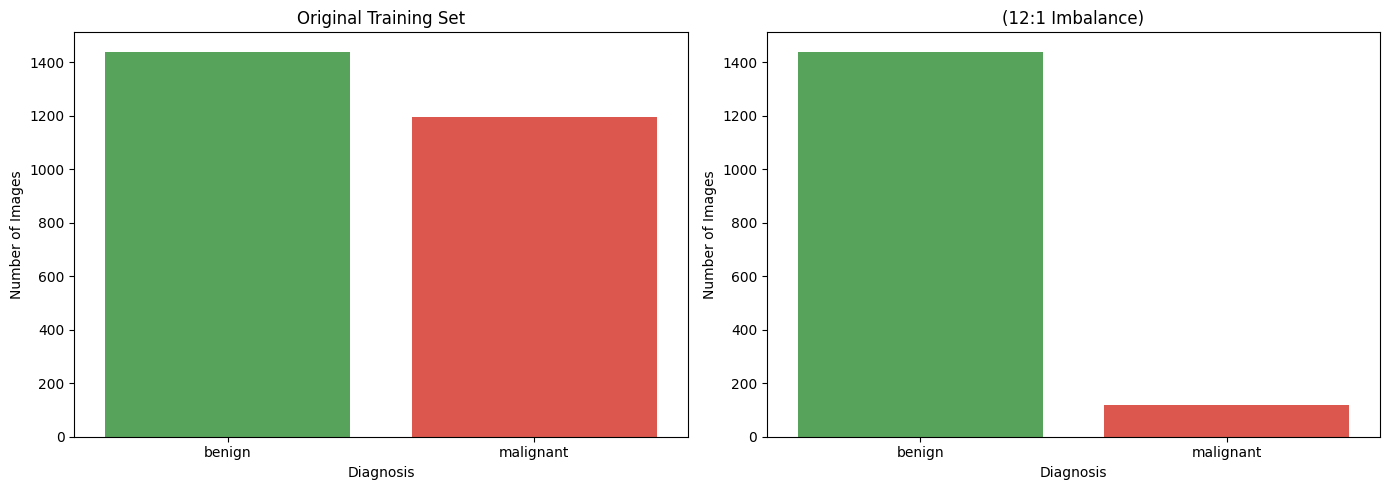

In [22]:
# Plot Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_colors = {'benign': '#4CAF50', 'malignant': '#F44336'} # Green for Benign, Red for Malignant

# Plot 1: The Original Dataset
sns.countplot(data=df_train_full, x='label', hue='label', ax=axes[0], palette=palette_colors, order=['benign', 'malignant'], legend=False)
axes[0].set_title("Original Training Set")
axes[0].set_ylabel("Number of Images")
axes[0].set_xlabel("Diagnosis")

# Plot 2: The Artificially Imbalanced Dataset
sns.countplot(data=df_train_imbalanced, x='label', hue='label', ax=axes[1], palette=palette_colors, order=['benign', 'malignant'], legend=False)
axes[1].set_title("(12:1 Imbalance)")
axes[1].set_ylabel("Number of Images")
axes[1].set_xlabel("Diagnosis")

plt.tight_layout()
plt.show()

In [23]:
def verify_all_image_sizes(df_list):
    unique_sizes = set()

    for df in df_list:
        for path in df['path']:
            with Image.open(path) as img:
                unique_sizes.add(img.size)

    print("\nUnique image dimensions found (Width x Height):")
    for size in unique_sizes:
        print(f"- {size[0]} x {size[1]}")

verify_all_image_sizes([df_train_full, df_test])


Unique image dimensions found (Width x Height):
- 224 x 224


In [24]:
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {'benign': 0.0, 'malignant': 1.0}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[self.dataframe.iloc[idx]['label']]

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

## **Baseline Model**

In [25]:
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Failsafe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
])

In [26]:
train_dataset = ISICDataset(df_train_imbalanced, transform=baseline_transforms)
val_dataset   = ISICDataset(df_val, transform=baseline_transforms)
test_dataset  = ISICDataset(df_test_final, transform=baseline_transforms)

In [27]:
train_baseline_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
def get_optimal_baseline():
    """Returns a ResNet18 with a regularized head"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze the foundational layers to focus learning on our specific data
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classification head and inject 50% Dropout
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 1) # binary classification
    )
    return model.to(DEVICE)

In [ ]:
def train_model(model, train_loader):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': []}

    print(f"Starting Training on {DEVICE} for {TRAINING_EPOCHS} epochs...")
    # EARLY STOPPING & BEST MODEL TRACKING SETUP
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    patience=5

    for epoch in range(TRAINING_EPOCHS):
        # Training Phase
        model.train()
        train_losses, train_preds, train_targets = [], [], []

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            # Clear old gradients
            optimizer.zero_grad()
            # Forward pass
            outputs = model(images)
            # Calculate loss
            loss = criterion(outputs, labels)
            # Backward pass
            loss.backward()
            # Update weights
            optimizer.step()

            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        history['train_loss'].append(np.mean(train_losses))
        history['train_acc'].append(accuracy_score(train_targets, train_preds))

        # Validation Phase
        model.eval()
        val_losses, val_preds, val_targets = [], [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        current_val_loss = np.mean(val_losses)
        history['val_loss'].append(current_val_loss)
        history['val_acc'].append(accuracy_score(val_targets, val_preds))
        history['val_recall'].append(recall_score(val_targets, val_preds, zero_division=0))

        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Recall: {history['val_recall'][-1]:.4f}")

        if current_val_loss < best_loss:
            best_loss = current_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs. Validation loss hasn't improved for {patience} epochs.")
                break
    print(f"Training complete. Loading best model weights (Val Loss: {best_loss:.4f})")
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='orange')
    ax1.set_title(f'{model_name} Loss (Early Stopping Tracked)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot 2: Validation Accuracy vs Recall
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='green')
    ax2.plot(history['val_recall'], label='Malignant Recall', color='red', linestyle='--')
    ax2.set_title(f'{model_name} Performance Metrics')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
from accelerate import Accelerator
accelerator = Accelerator()
DEVICE = accelerator.device

# Train Baseline
baseline_model = get_optimal_baseline()
trained_baseline, baseline_history = train_model(model=baseline_model, train_loader=train_baseline_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 70.3MB/s]


Starting Training on cuda for 15 epochs...
Epoch [1/15] | Train Loss: 0.5095 | Val Loss: 1.0523 | Val Recall: 0.0000
Epoch [2/15] | Train Loss: 0.3260 | Val Loss: 1.2418 | Val Recall: 0.0000
Epoch [3/15] | Train Loss: 0.3074 | Val Loss: 1.2931 | Val Recall: 0.0000
Epoch [4/15] | Train Loss: 0.3036 | Val Loss: 1.2753 | Val Recall: 0.0000
Epoch [5/15] | Train Loss: 0.2984 | Val Loss: 1.2670 | Val Recall: 0.0000
Epoch [6/15] | Train Loss: 0.2878 | Val Loss: 1.1991 | Val Recall: 0.0000

Early stopping triggered after 6 epochs. Validation loss hasn't improved for 5 epochs.
Training complete. Loading best model weights (Val Loss: 1.0523)


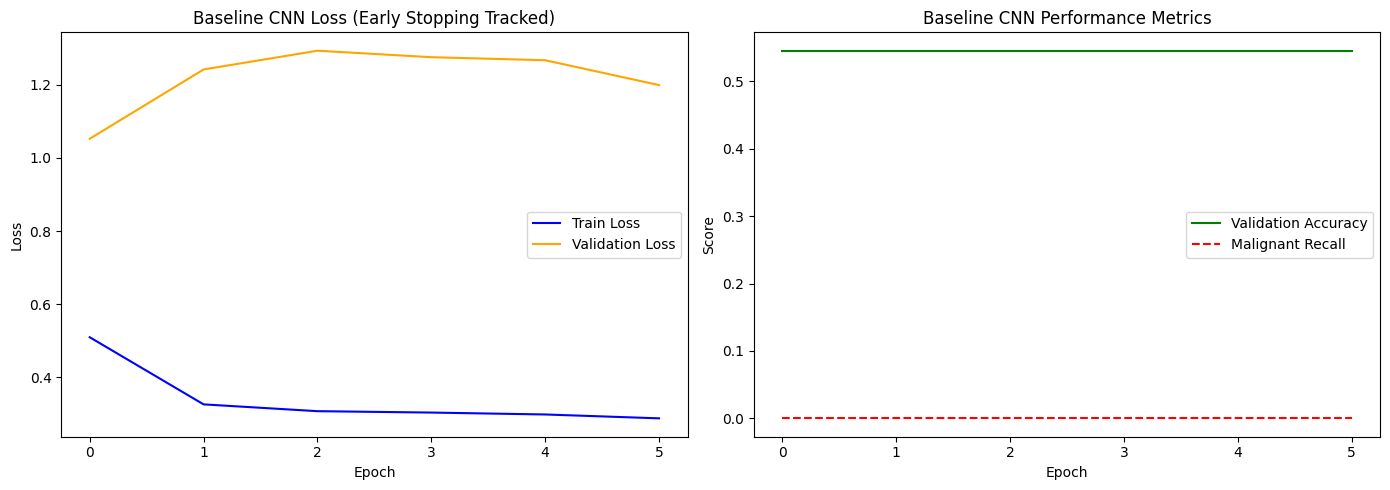

In [ ]:
plot_training_history(baseline_history, model_name="Baseline CNN")

## **Augmented Model**

In [ ]:
# 1. OVERSAMPLING: Balance the DataFrame
# Grab the 120 malignant images and duplicate them 12 times
train_malignant_oversampled = pd.concat([train_malignant_imbalanced] * 12, ignore_index=True)

# Combine with the 1440 benign images and shuffle
df_train_augmented = pd.concat([train_benign, train_malignant_oversampled]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"New Balanced Training Set Size: {len(df_train_augmented)}")
print(df_train_augmented["label"].value_counts())

# 2. Classical Augmentation
augmented_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Failsafe

    transforms.RandomHorizontalFlip(p=0.5), # 50% chance to flip left-to-right
    transforms.RandomVerticalFlip(p=0.5), # 50% chance to flip upside down
    transforms.RandomRotation(degrees=45), # Randomly tilt the image anywhere from -45 to +45 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Slightly shift the lighting

    transforms.ToTensor(), # Convert to math (decimals)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #Standardize the colors
])

New Balanced Training Set Size: 2880
label
benign       1440
malignant    1440
Name: count, dtype: int64


In [ ]:
# Create the specific dataset for Classical Augmentation
train_augmented_dataset = ISICDataset(df_train_augmented, transform=augmented_transforms)
# Create the specific dataloader
train_augmented_loader = DataLoader(train_augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
import torch

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

print("--- Starting Experiment 2: Classical Augmentation ---")
augmented_model = get_optimal_baseline()
trained_augmented, augmented_history = train_model(model=augmented_model, train_loader=train_augmented_loader)

cuda:0
--- Starting Experiment 2: Classical Augmentation ---
Starting Training on cuda:0 for 15 epochs...
Epoch [1/15] | Train Loss: 0.6913 | Val Loss: 0.6418 | Val Recall: 0.7067
Epoch [2/15] | Train Loss: 0.6336 | Val Loss: 0.5949 | Val Recall: 0.7400
Epoch [3/15] | Train Loss: 0.5945 | Val Loss: 0.5766 | Val Recall: 0.9000
Epoch [4/15] | Train Loss: 0.5573 | Val Loss: 0.5584 | Val Recall: 0.9200
Epoch [5/15] | Train Loss: 0.5356 | Val Loss: 0.5406 | Val Recall: 0.9333
Epoch [6/15] | Train Loss: 0.5110 | Val Loss: 0.5453 | Val Recall: 0.9600
Epoch [7/15] | Train Loss: 0.5015 | Val Loss: 0.5201 | Val Recall: 0.9467
Epoch [8/15] | Train Loss: 0.4885 | Val Loss: 0.5183 | Val Recall: 0.9533
Epoch [9/15] | Train Loss: 0.4826 | Val Loss: 0.5122 | Val Recall: 0.9533
Epoch [10/15] | Train Loss: 0.4564 | Val Loss: 0.5071 | Val Recall: 0.9667
Epoch [11/15] | Train Loss: 0.4607 | Val Loss: 0.5063 | Val Recall: 0.9733
Epoch [12/15] | Train Loss: 0.4574 | Val Loss: 0.5112 | Val Recall: 0.9867
Epo

In [ ]:
import torch
from google.colab import files

model_save_path = "classical_aug.pth"
torch.save(trained_augmented.state_dict(), model_save_path)
print(f"Model saved successfully to {model_save_path}")

files.download(model_save_path)

Model saved successfully to classical_aug.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

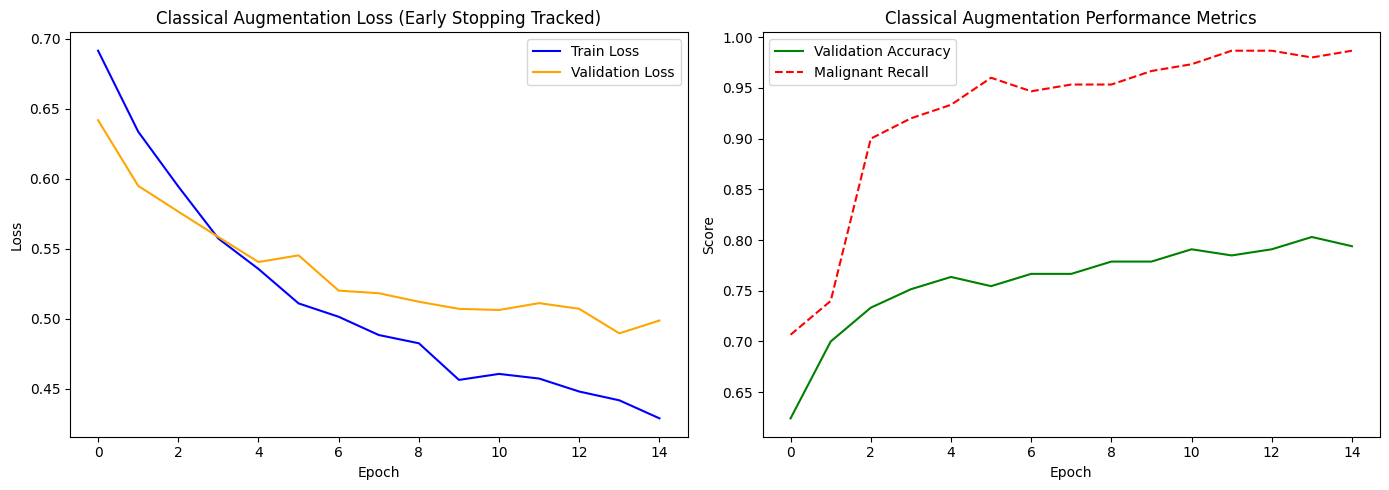


Evaluating Classical Augmentation on Final Test Set...

--- Classical Augmentation Clinical Metrics ---
Recall (Sensitivity): 0.9267 -> Goal: Catch all Cancer
Specificity:          0.7333 -> Goal: Don't scare healthy patients
Precision:            0.7433
F1-Score:             0.8249


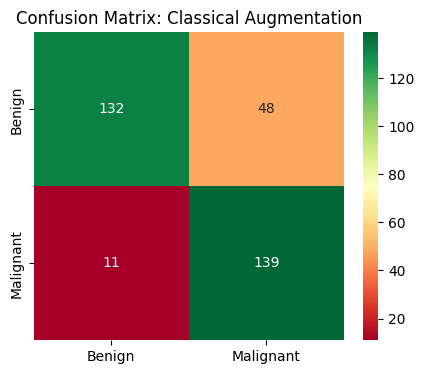

In [ ]:
plot_training_history(augmented_history, model_name="Classical Augmentation")

print("\nEvaluating Classical Augmentation on Final Test Set...")
augmented_results = evaluate_model_performance(trained_augmented, test_loader, model_name="Classical Augmentation")

## **GAN Model**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score

def evaluate_model_performance(model, dataloader, model_name="Model"):
    model.eval()
    all_preds = []
    all_targets = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    # Core Metrics
    tn, fp, fn, tp = confusion_matrix(all_targets, all_preds).ravel()

    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall / Sensitivity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0 # Specificity
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    print(f"\n--- {model_name} Clinical Metrics ---")
    print(f"Recall (Sensitivity): {rec:.4f} -> Goal: Catch all Cancer")
    print(f"Specificity:          {spec:.4f} -> Goal: Don't scare healthy patients")
    print(f"Precision:            {prec:.4f}")
    print(f"F1-Score:             {f1:.4f}")

    # Visualization
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return {"acc": acc, "prec": prec, "rec": rec, "spec": spec, "f1": f1}

In [ ]:
from torch.utils.data import Subset
from torchvision import utils

# --- CONFIGURATION ---
IMG_CHANNELS = 3
IMG_SIZE = 64     # Resize 224x224 images down
Z_DIM = 100
FEATURES_G = 64
FEATURES_D = 64
LR = 2e-4
BATCH_SIZE = 32
GAN_EPOCHS = 50

# --- DATA PREPARATION (Targeting the 120 Malignant Images) ---

# Need [-1, 1] normalization to match Generator's Tanh output
gan_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Filter df_train_imbalanced for ONLY malignant cases
df_malignant_only = df_train_imbalanced[df_train_imbalanced['label'] == 'malignant']
gan_dataset = ISICDataset(df_malignant_only, transform=gan_transforms)
gan_loader = DataLoader(gan_dataset, batch_size=BATCH_SIZE, shuffle=True)


# --- MODELS ---
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            self._block(z_dim, features_g * 16, 4, 1, 0), # 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1), # 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1), # 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1), # 32x32
            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1), # 64x64
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, 4, 2, 1), # 32x32
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 16x16
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1), # 4x4
            nn.Conv2d(features_d * 8, 1, 4, 2, 0), # 1x1
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [ ]:
def visualize_gan_output(gen, num_images=16):
    gen.eval()
    device = next(gen.parameters()).device

    # Generate noise on the SAME device as the model
    noise = torch.randn(num_images, Z_DIM, 1, 1).to(device)

    with torch.no_grad():
        # Generate images
        fake_images = gen(noise)
        # Denormalize from [-1, 1] to [0, 1]
        fake_images = (fake_images * 0.5) + 0.5
        # Move to CPU and detach from graph for plotting
        fake_images = fake_images.detach().cpu()

    # Create the grid
    grid = utils.make_grid(fake_images, nrow=4).permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,8))
    plt.imshow(grid)
    plt.axis('off')
    plt.show()

    # Train
    gen.train()

Training GAN on 120 malignant images...
Epoch [0/50] Loss D: 0.5721, Loss G: 0.9875


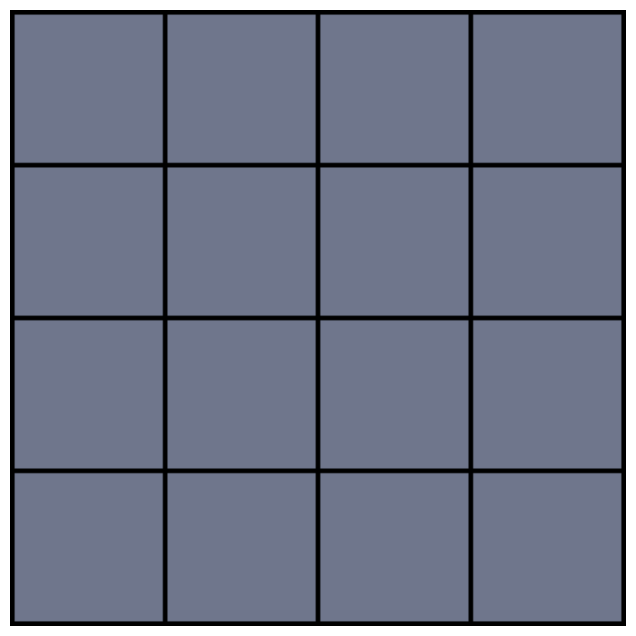

Epoch [10/50] Loss D: 0.2033, Loss G: 2.6293
Epoch [20/50] Loss D: 0.1784, Loss G: 3.6298


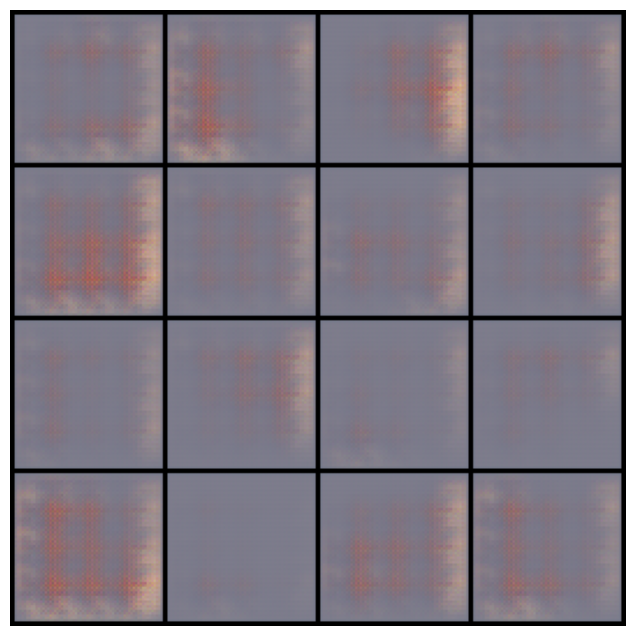

Epoch [30/50] Loss D: 0.5747, Loss G: 1.1642
Epoch [40/50] Loss D: 0.6410, Loss G: 2.2992


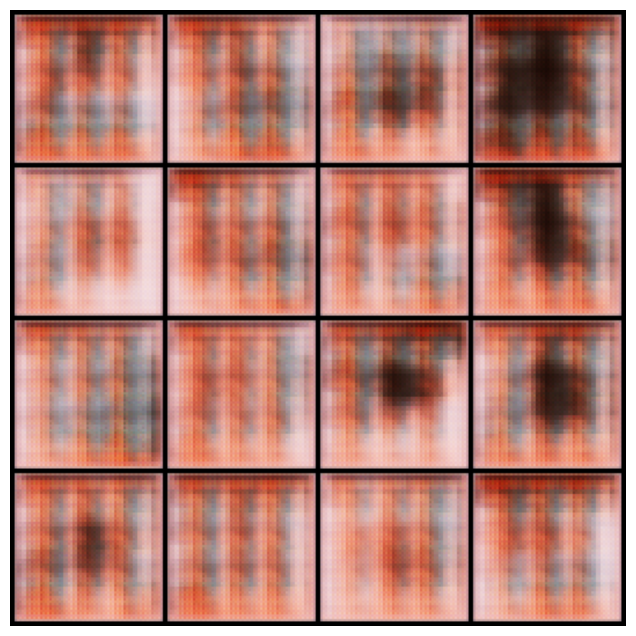

GAN Training Complete. Model saved.


In [ ]:
# --- TRAINING FUNCTION ---
def train_gan(dataloader):
    accelerator = Accelerator()
    device = accelerator.device

    gen = Generator(Z_DIM, IMG_CHANNELS, FEATURES_G)
    disc = Discriminator(IMG_CHANNELS, FEATURES_D)
    initialize_weights(gen)
    initialize_weights(disc)

    opt_gen = torch.optim.Adam(gen.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_disc = torch.optim.Adam(disc.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    gen, disc, opt_gen, opt_disc, dataloader = accelerator.prepare(
        gen, disc, opt_gen, opt_disc, dataloader
    )

    print(f"Training GAN on {len(dataloader.dataset)} malignant images...")

    for epoch in range(GAN_EPOCHS):
        for batch_idx, (real, _) in enumerate(dataloader):
            curr_batch_size = real.size(0)

            # TRAIN DISCRIMINATOR
            noise = torch.randn(curr_batch_size, Z_DIM, 1, 1).to(device)
            fake = gen(noise)

            disc_real = disc(real).reshape(-1)
            loss_disc_real = criterion(disc_real, torch.ones_like(disc_real) * 0.9) # Label Smoothing

            disc_fake = disc(fake.detach()).reshape(-1)
            loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

            loss_disc = (loss_disc_real + loss_disc_fake) / 2
            opt_disc.zero_grad()
            accelerator.backward(loss_disc)
            opt_disc.step()

            # TRAIN GENERATOR
            output = disc(fake).reshape(-1)
            loss_gen = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad()
            accelerator.backward(loss_gen)
            opt_gen.step()

        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{GAN_EPOCHS}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

        if epoch % 20 == 0:
            # Save a sample grid of 16 images to see if they are getting better
            # or if they are all starting to look exactly the same (Mode Collapse)
            visualize_gan_output(accelerator.unwrap_model(gen), num_images=16)

    # Save final model
    unwrapped_gen = accelerator.unwrap_model(gen)
    torch.save(unwrapped_gen.state_dict(), "malignant_generator.pth")
    print("GAN Training Complete. Model saved.")
    return unwrapped_gen

# Execute
trained_gen = train_gan(gan_loader)

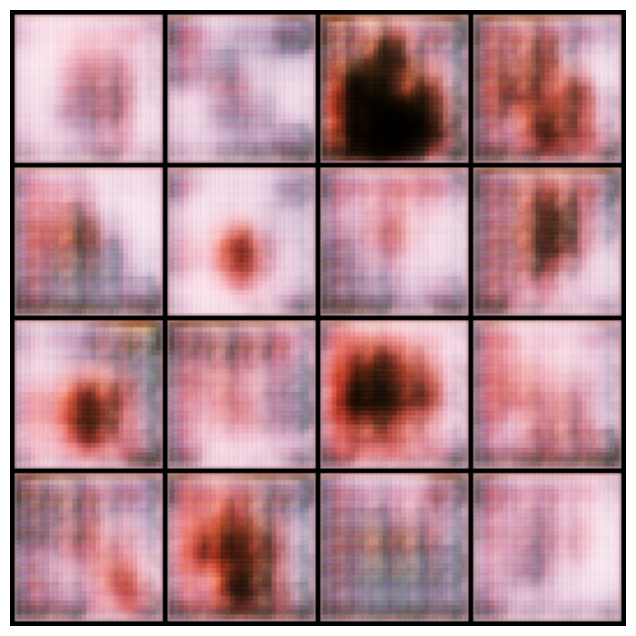

In [ ]:
visualize_gan_output(trained_gen)

In [ ]:
output_dir = './gan_boosted_data'
os.makedirs(output_dir, exist_ok=True)

def generate_and_save_boost(gen, count=1320):
    gen.eval()
    device = next(gen.parameters()).device

    # Generate in batches to avoid memory errors
    batch_size = 64
    for i in range(0, count, batch_size):
        num_to_gen = min(batch_size, count - i)
        noise = torch.randn(num_to_gen, Z_DIM, 1, 1).to(device)

        with torch.no_grad():
            fakes = gen(noise).cpu()
            fakes = (fakes * 0.5) + 0.5 # To [0, 1]

        for j in range(num_to_gen):
            img = transforms.ToPILImage()(fakes[j])
            img.save(os.path.join(output_dir, f"gan_fake_{i+j}.jpg"))

generate_and_save_boost(trained_gen)

Starting Training on cuda for 15 epochs...
Epoch [1/15] | Train Loss: 0.5739 | Val Loss: 0.7327 | Val Recall: 0.1000
Epoch [2/15] | Train Loss: 0.3893 | Val Loss: 0.7774 | Val Recall: 0.0267
Epoch [3/15] | Train Loss: 0.2960 | Val Loss: 0.8389 | Val Recall: 0.0200
Epoch [4/15] | Train Loss: 0.2472 | Val Loss: 0.8272 | Val Recall: 0.0200
Epoch [5/15] | Train Loss: 0.2251 | Val Loss: 0.8879 | Val Recall: 0.0133
Epoch [6/15] | Train Loss: 0.1935 | Val Loss: 0.9430 | Val Recall: 0.0133

Early stopping triggered after 6 epochs. Validation loss hasn't improved for 5 epochs.
Training complete. Loading best model weights (Val Loss: 0.7327)


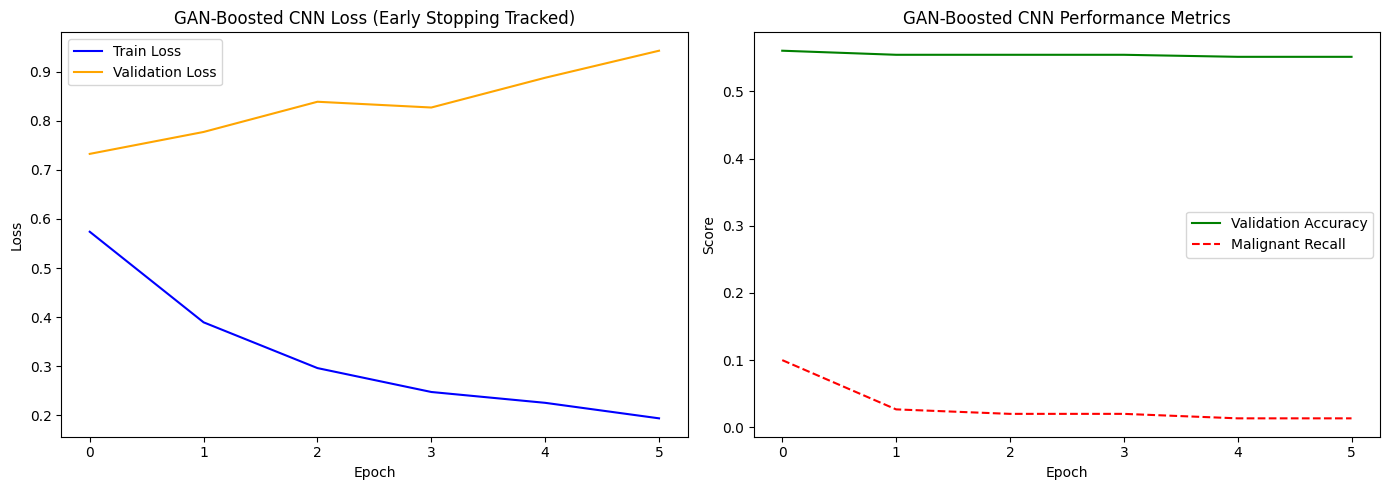

In [ ]:
# Create paths for the new synthetic images
gan_paths = [os.path.join(output_dir, f) for f in os.listdir(output_dir)]
df_gan_synthetic = pd.DataFrame({'path': gan_paths, 'label': 'malignant'})

# Combine with the imbalanced training set
# Result: 1,440 Benign vs (120 Real Malignant + 1,320 Fake Malignant) = 1,440 Malignant
df_train_gan_hybrid = pd.concat([df_train_imbalanced, df_gan_synthetic]).sample(frac=1).reset_index(drop=True)

# Update Dataloader
train_gan_hybrid_dataset = ISICDataset(df_train_gan_hybrid, transform=baseline_transforms)
train_gan_hybrid_loader = DataLoader(train_gan_hybrid_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Train the "Experiment 3" Model
hybrid_model = get_optimal_baseline()
trained_hybrid, hybrid_history = train_model(model=hybrid_model, train_loader=train_gan_hybrid_loader)

# Plot comparison
plot_training_history(hybrid_history, model_name="GAN-Boosted CNN")

Evaluating Baseline...

--- Baseline CNN Clinical Metrics ---
Recall (Sensitivity): 0.0000 -> Goal: Catch all Cancer
Specificity:          1.0000 -> Goal: Don't scare healthy patients
Precision:            0.0000
F1-Score:             0.0000


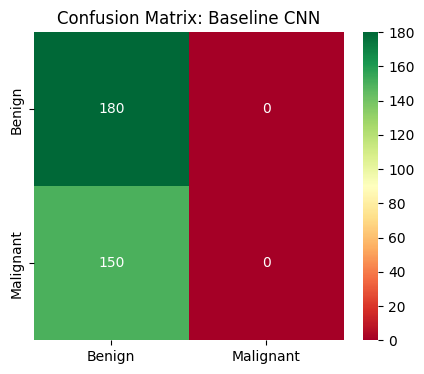


Evaluating GAN-Hybrid...

--- GAN-Boosted CNN Clinical Metrics ---
Recall (Sensitivity): 0.0867 -> Goal: Catch all Cancer
Specificity:          0.9667 -> Goal: Don't scare healthy patients
Precision:            0.6842
F1-Score:             0.1538


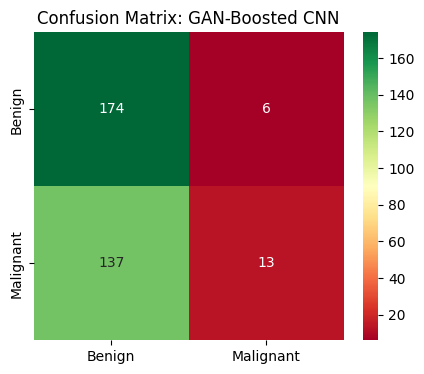

In [ ]:
print("Evaluating Baseline...")
baseline_results = evaluate_model_performance(trained_baseline, test_loader, "Baseline CNN")

print("\nEvaluating GAN-Hybrid...")
hybrid_results = evaluate_model_performance(trained_hybrid, test_loader, "GAN-Boosted CNN")

--- Final Benchmark Comparison ---
     Metric  Baseline (12:1)  GAN-Hybrid (Balanced)
   Accuracy         0.545455               0.566667
  Precision         0.000000               0.684211
     Recall         0.000000               0.086667
Specificity         1.000000               0.966667
   F1-Score         0.000000               0.153846


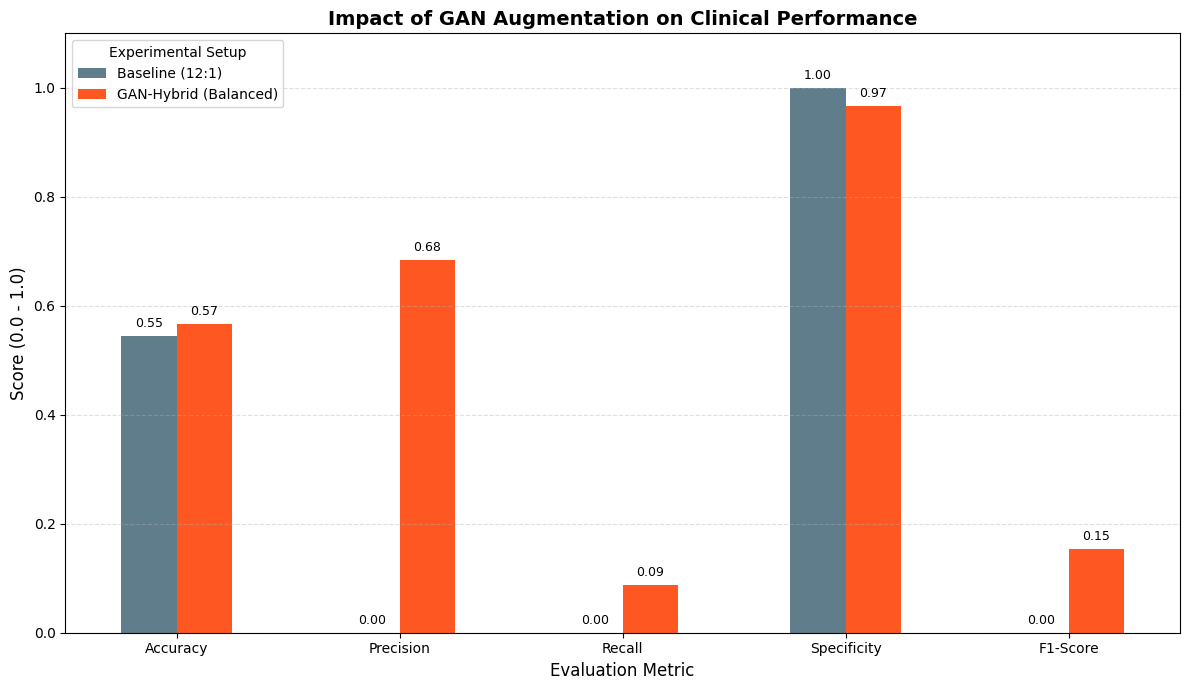

In [ ]:
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score'],
    'Baseline (12:1)': [
        baseline_results['acc'],
        baseline_results['prec'],
        baseline_results['rec'],
        baseline_results['spec'],
        baseline_results['f1']
    ],
    'GAN-Hybrid (Balanced)': [
        hybrid_results['acc'],
        hybrid_results['prec'],
        hybrid_results['rec'],
        hybrid_results['spec'],
        hybrid_results['f1']
    ]
}

# Create and Print DataFrame
df_compare = pd.DataFrame(comparison_data)
print("--- Final Benchmark Comparison ---")
print(df_compare.to_string(index=False))

# Enhanced Visualization
df_compare.set_index('Metric').plot(kind='bar', figsize=(12, 7), color=['#607D8B', '#FF5722'])

plt.title("Impact of GAN Augmentation on Clinical Performance", fontsize=14, fontweight='bold')
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Experimental Setup", loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Top data labels
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontsize=9)

plt.tight_layout()
plt.show()

GAN 50 epochs:
```
--- Final Benchmark Comparison ---
     Metric  Baseline (12:1)  GAN-Hybrid (Balanced)
   Accuracy         0.542424               0.548485
  Precision         0.000000               0.518519
     Recall         0.000000               0.093333
Specificity         0.994444               0.927778
   F1-Score         0.000000               0.158192
```

GAN 70 epochs:
```
--- Final Benchmark Comparison ---
     Metric  Baseline (12:1)  GAN-Hybrid (Balanced)
   Accuracy         0.542424               0.548485
  Precision         0.000000               0.666667
     Recall         0.000000               0.013333
Specificity         0.994444               0.994444
   F1-Score         0.000000               0.026144
```


GAN 100 epochs:
```
--- Final Benchmark Comparison ---
     Metric  Baseline (12:1)  GAN-Hybrid (Balanced)
   Accuracy         0.542424               0.551515
  Precision         0.000000               0.583333
     Recall         0.000000               0.046667
Specificity         0.994444               0.972222
   F1-Score         0.000000               0.086420
```

In [ ]:
# Final Export of the GAN-Boosted CNN
final_model_path = "gan_boosted_resnet18.pth"

# If train_model returns an accelerated model, unwrap it
if hasattr(trained_hybrid, 'module'):
    torch.save(trained_hybrid.module.state_dict(), final_model_path)
else:
    torch.save(trained_hybrid.state_dict(), final_model_path)

print(f"✅ Successfully exported GAN-Boosted weights to {final_model_path}")

# Verify file size to make sure it saved correctly
model_size = os.path.getsize(final_model_path) / (1024 * 1024)
print(f"Model File Size: {model_size:.2f} MB")

✅ Successfully exported GAN-Boosted weights to gan_boosted_resnet18.pth
Model File Size: 42.71 MB


## **Final Benchmark**

In [47]:
import torch

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# Instantiate thre blank, models
model_baseline = get_optimal_baseline()
model_classical = get_optimal_baseline()
model_gan = get_optimal_baseline() # Uncomment when I get model weights
#model_diffusion = get_optimal_baseline() # Uncomment when I get model weights

# Inject model weights
model_baseline.load_state_dict(torch.load("baseline_CNN.pth", map_location=DEVICE))
model_classical.load_state_dict(torch.load("classical_CNN.pth", map_location=DEVICE))
model_gan.load_state_dict(torch.load("gan_CNN.pth", map_location=DEVICE))
#model_diffusion.load_state_dict(torch.load("diffusion_CNN.pth", map_location=DEVICE))

# Put all models in "Test Mode"
model_baseline.eval()
model_classical.eval()
model_gan.eval()
#model_diffusion.eval()

# Group them into a dictionary for Master Evaluator
final_models_dict = {
    "Baseline": model_baseline,
    "Classical Augmentation": model_classical,
    "GAN Augmentation": model_gan,
    #"Diffusion Augmentation": model_diffusion
}
print("\nAll available models successfully loaded and prepped")

cuda:0

All available models successfully loaded and prepped


In [48]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

# Strictly define the Baseline
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset_fixed = ISICDataset(df_test_final, transform=baseline_transforms)

test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=BATCH_SIZE, shuffle=False)


In [49]:
"""
MASTER EVALUATOR FUNCTION
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_all_models(models_dict, dataloader):
  """
  Takes a dictionary of models, tests them all on the final dataloader, and
  outputs a side-by-side heatmap grid and a master report card.
  """
  metrics_list = []
  cm_dict = {} # Dictionary to hold the confusion matrices for painting later

  # Figure out if we are using the CPU or GPU based on the first model
  device = next(iter(models_dict.values())).parameters().__next__().device
  print(f"Evaluating on {device}")

  for model_name, model in models_dict.items():
    print(f"Evaluating for: {model_name}...")
    model.eval() # Turn off Dropout blindfolds
    all_preds, all_targets = [], []

    # No learning allowed
    with torch.no_grad():
      for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Convert the AI's math into a simple 0 (Benign) or 1 (Malignant)
        preds = (torch.sigmoid(outputs) >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

    # Build the Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    cm_dict[model_name] = cm # Save the matrix for painting later

    # Extract metrics
    tn, fp, fn, tp = cm.ravel()

    # Calculate the metrics
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # Save the reports to master list
    metrics_list.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": spec,
        "F1-Score": f1
    })

  # Build a clean Pandas DataFrame from our list of report cards
  df_results = pd.DataFrame(metrics_list)

  # Dynamically figure out how many side-by-side canvases we need
  num_models = len(models_dict)
  fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

  # Safety check: If there's only 1 model, force it into a list
  if num_models == 1: axes = [axes]

  # Paint each Confusion Matrix onto its specific canvas slot
  for ax, (model_name, cm) in zip(axes, cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap="RdYlGn", ax=ax,
                xticklabels=["Predicted Benign", "Predicted Malignant"],
                yticklabels=["Actually Benign", "Actually Malignant"],
                annot_kws={"size": 14}) # Make the numbers big and readable
    ax.set_title(f"Confusion Matrix:\n{model_name}", fontweight="bold")

  plt.tight_layout()
  plt.show()

  return df_results

Evaluating on cuda:0
Evaluating for: Baseline...
Evaluating for: Classical Augmentation...
Evaluating for: GAN Augmentation...


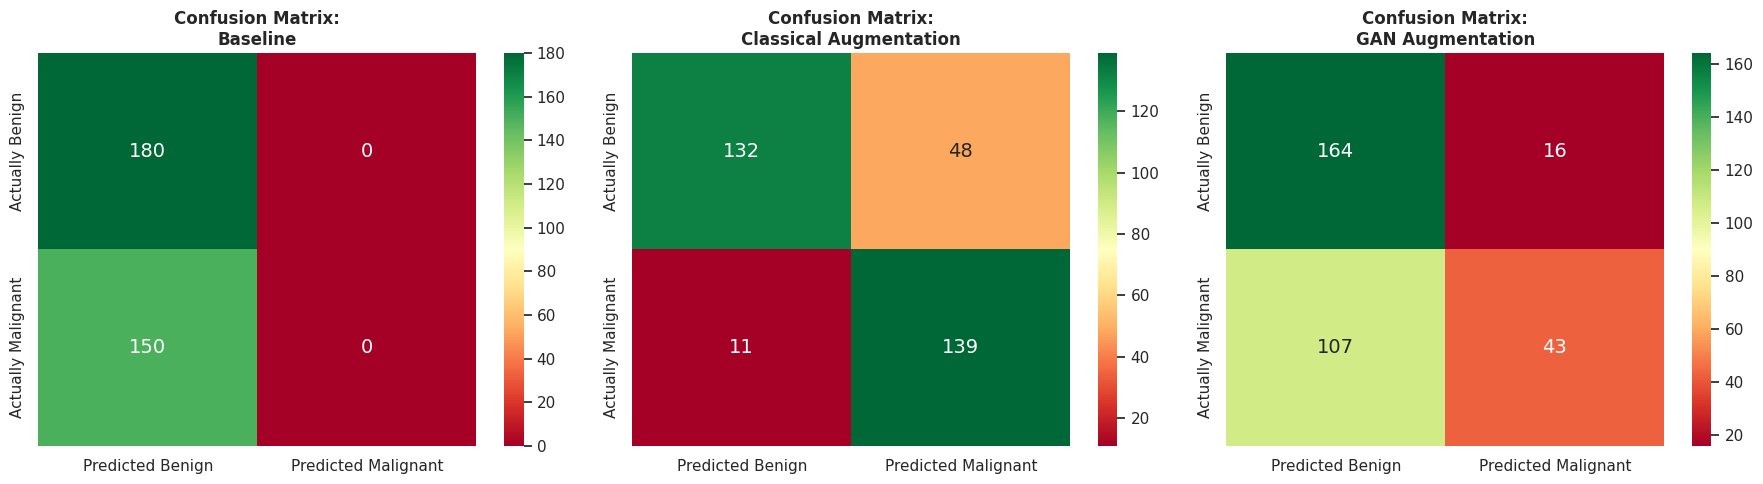


--- FINAL BENCHMARK REPORT ---


,Model,Accuracy,Precision,Recall,Specificity,F1-Score
0,Baseline,0.5455,0.0000,0.0000,1.0000,0.0000
1,Classical Augmentation,0.8212,0.7433,0.9267,0.7333,0.8249
2,GAN Augmentation,0.6273,0.7288,0.2867,0.9111,0.4115


In [50]:
final_card = evaluate_all_models(final_models_dict, test_loader_fixed)

print("\n--- FINAL BENCHMARK REPORT ---")
display(final_card.round(4))

Generating the Final Benchmark Bar Char...


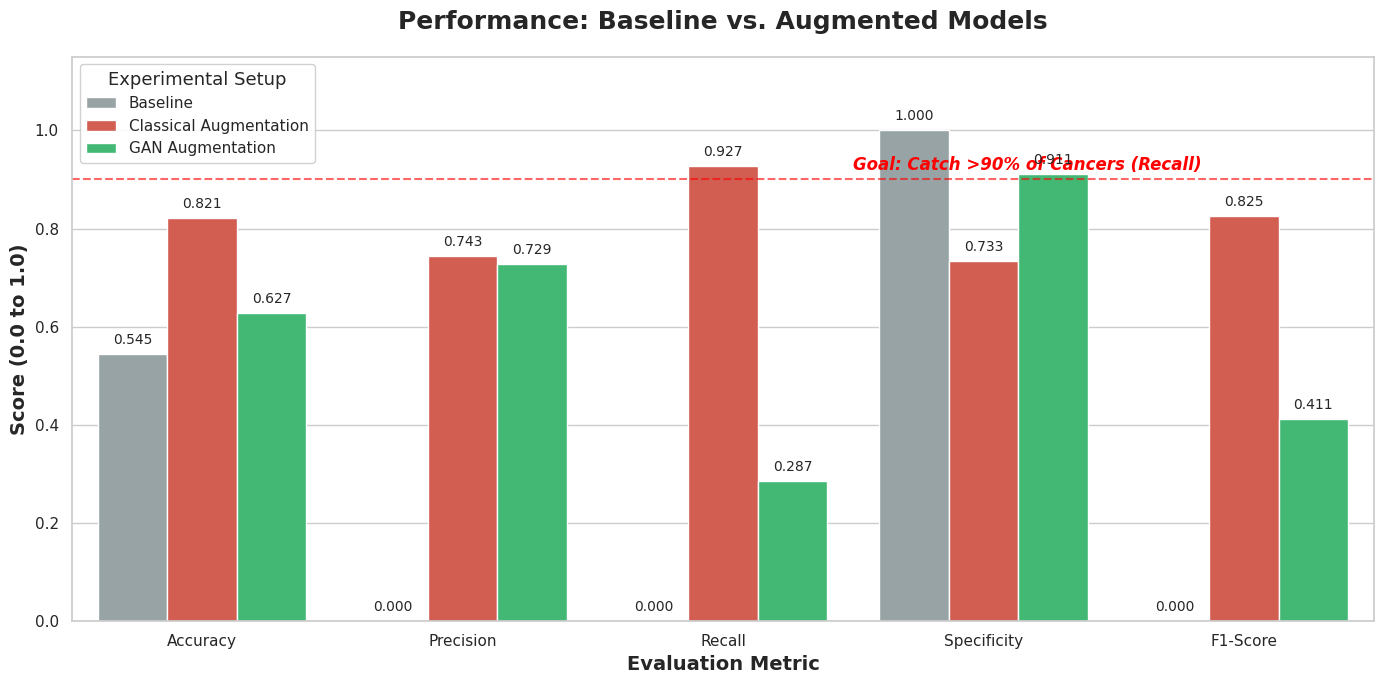

In [51]:
"""
FINAL BENCHMARK BAR CHART
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating the Final Benchmark Bar Char...")

# "Melt" the data: Seaborn needs the spreadsheet reformatted to draw grouped
# bars
df_melted = pd.melt(final_card, id_vars=["Model"], var_name="Metric", value_name="Score")

# Set up the Canvas and Theme
plt.figure(figsize=(14,7))
sns.set_theme(style="whitegrid") # Adds clean, professional background lines

# Paint the Grouped Bar Chart
colors = ["#95a5a6", "#e74c3c", "#2ecc71", "#3498db"]
ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette=colors[:len(final_models_dict)])

# Titles and Labels
plt.title("Performance: Baseline vs. Augmented Models", fontsize=18, fontweight="bold", pad=20)
plt.ylabel("Score (0.0 to 1.0)", fontsize=14, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=14, fontweight="bold")
plt.ylim(0, 1.15) # Give the bars some breathing room at the top
plt.legend(title="Experimental Setup", fontsize=11, title_fontsize=13, loc="upper left", framealpha=0.9)

# Highlight the Recall Goal
# Draw a red dashed line across the chart at 90% to show the medical standard
plt.axhline(y=0.90, color="red", linestyle="--", alpha=0.6)
plt.text(x=2.5, y=0.92, s="Goal: Catch >90% of Cancers (Recall)", color="red", fontsize=12, fontweight="bold", style="italic")

# Add the exact numbers on top of every single bar
for container in ax.containers:
  ax.bar_label(container, fmt="%.3f", padding=5, size=10, fontweight="medium")

plt.tight_layout()
plt.show()